In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import h5py
import scipy.io as sio 
import numpy as np
import matplotlib.pyplot as plt
from ptychozoon.enhance import ElementMap, FluorescenceDataset, Product, VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.enhance import VSPIFluorescenceEnhancingAlgorithm
from ptychozoon.settings import DeconvolutionEnhancementSettings
from ptychozoon.settings import InterpolationTypes
from chronos import plotting
from chronos.timer_utils import toggle_timer, clear_timer_globals

## Generate Data

### 1. Make ptycho array and fluorescence arrays

In [8]:
file_path = "/net/micdata/data1/bnp/2023-1/Isaure_fly0085_for_SH/results/ML_recon/fly085/roi0_Ndp256/MLs_L1_p10_g1000_Ndp64_pc50_noModelCon_bg0.1_vp5_vi_mm/Niter1000.mat"
d = sio.loadmat(file_path)
pixel_size_m = 1
input_object_array = d["object"]
object_size = input_object_array.shape
padding = 64

object_size

(436, 353)

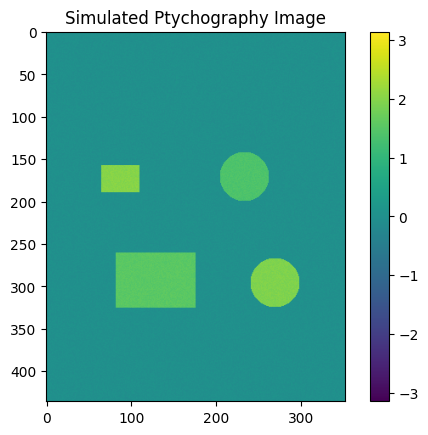

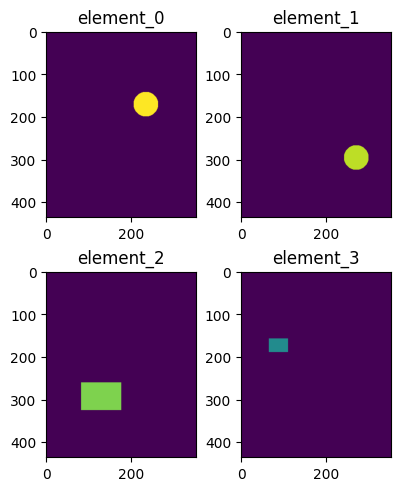

In [10]:
import numpy as np
from skimage.draw import disk, rectangle

rng = np.random.default_rng(42)

# Background: magnitude ~1, phase ~0
# INPUTS
# object_size = (500, 450) #(400, 300)
# object_size = (400, 300)
# padding = 64

margin = padding // 2
object_array = np.zeros(object_size, dtype=np.complex128)
object_array[:] = np.exp(1j * 0.1 * rng.uniform(-1, 1, object_size))

def add_shape(arr, mask, phase, amplitude=1.0):
    """Apply a complex value to a masked region."""
    # Small amplitude variation (0.85–1.0) but large phase variation
    mag = amplitude * rng.uniform(0.85, 1.0)
    arr[mask] = mag * np.exp(1j * phase) * arr[mask]

def add_shape_element_map(arr, mask, amplitude=1.0):
    mag = amplitude * rng.uniform(0.2, 1.0)
    arr[mask] = mag


element_maps_truth = []
n_circles = 2
for i in range(n_circles):
    radius = rng.integers(15, 50)
    cy = rng.integers(margin + radius, object_size[0] - radius - margin)
    cx = rng.integers(margin + radius, object_size[1] - radius - margin)
    rr, cc = disk((cy, cx), radius, shape=object_size)
    phase = rng.uniform(0.5, 2.8)  # strong phase, radians
    add_shape(object_array, (rr, cc), phase)
    # make element map
    counts = np.zeros(object_size, dtype=np.float64)
    add_shape_element_map(counts, (rr, cc))
    element_maps_truth += [ElementMap(f"element_{i}", counts)]

n_rects = 2
for j in range(n_rects):
    h = rng.integers(20, 80)
    w = rng.integers(20, 100)
    r0 = rng.integers(margin, object_size[0] - h - margin)
    c0 = rng.integers(margin, object_size[1] - w - margin)
    rr, cc = rectangle((r0, c0), extent=(h, w), shape=object_size)
    phase = rng.uniform(0.5, 2.8)
    add_shape(object_array, (rr, cc), phase)
    # make element map
    counts = np.zeros(object_size, dtype=np.float64)
    add_shape_element_map(counts, (rr, cc))
    element_maps_truth += [ElementMap(f"element_{i+j+1}", counts)]

plt.title("Simulated Ptychography Image")
plt.imshow(np.angle(object_array))
plt.clim([-3.14, 3.14])
plt.colorbar()
plt.show()

n_maps = len(element_maps_truth)
fig, ax = plt.subplots(2, 2, layout="compressed")
for i in range(n_maps):
    plt.sca(ax.ravel()[i])
    plt.title(f"{element_maps_truth[i].name}")
    plt.imshow(element_maps_truth[i].counts_per_second)
    plt.clim([0, 1])
plt.show()

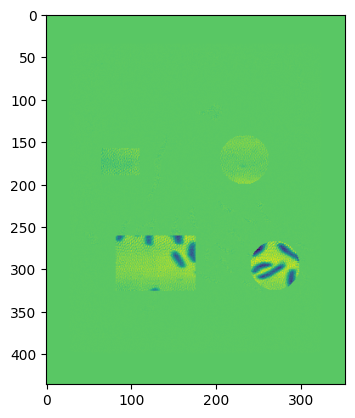

In [15]:
plt.imshow(np.angle(input_object_array) * np.angle(object_array))
plt.show()

### 2. Make probe positions

Grid: 217 rows x 138 cols = 29946 positions


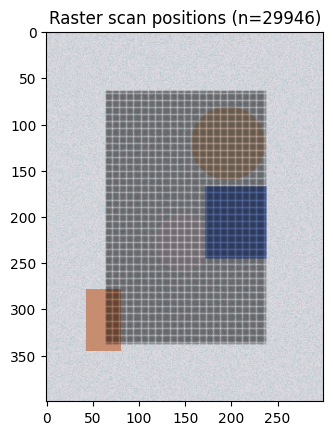

In [14]:
# Raster scan positions covering the area 'padding' pixels from the object edge
n_positions = 30e3  # approximate total; actual count = n_rows * n_cols

scan_row_min = padding
scan_row_max = object_size[0] - padding
scan_col_min = padding
scan_col_max = object_size[1] - padding

scan_height = scan_row_max - scan_row_min
scan_width  = scan_col_max - scan_col_min

# Grid dimensions that preserve the scan area aspect ratio
aspect = scan_height / scan_width
n_cols = max(1, int(np.round(np.sqrt(n_positions / aspect))))
n_rows = max(1, int(np.round(n_positions / n_cols)))

row_coords = np.linspace(scan_row_min, scan_row_max, n_rows)
col_coords = np.linspace(scan_col_min, scan_col_max, n_cols)

# Raster scan: all rows go left to right
positions = np.array([
    [r, c]
    for r in row_coords
    for c in col_coords
])  # shape: (n_rows * n_cols, 2)  —  axis 0 = row, axis 1 = col (pixels)

print(f"Grid: {n_rows} rows x {n_cols} cols = {len(positions)} positions")

# Visualise scan path overlaid on the object phase
plt.figure()
plt.imshow(np.angle(object_array), cmap="twilight", origin="upper")
plt.plot(positions[:, 1], positions[:, 0], ".k", lw=0.5, alpha=0.4, ms=.5)
plt.title(f"Raster scan positions (n={len(positions)})")
plt.show()

### 3. Make probe

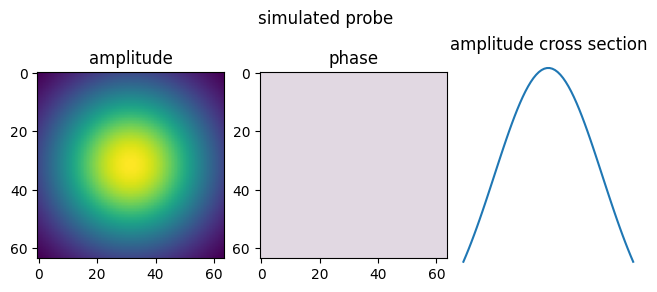

In [15]:
# Generate complex Gaussian probe
probe_size = (padding, padding)
probe_width = 20  # Gaussian sigma in pixels (user-settable)

# Coordinate grids centred on zero
y = np.linspace(-(probe_size[0] - 1) / 2, (probe_size[0] - 1) / 2, probe_size[0])
x = np.linspace(-(probe_size[1] - 1) / 2, (probe_size[1] - 1) / 2, probe_size[1])
Y, X = np.meshgrid(y, x, indexing="ij")

probe = np.exp(-(X**2 + Y**2) / (2 * probe_width**2)).astype(np.complex128)
probe /= np.sqrt(np.sum(np.abs(probe) ** 2))  # normalise to unit energy
probe /= np.abs(probe).sum()

fig, ax = plt.subplots(1, 3, layout="compressed")
fig.suptitle("simulated probe")
plt.sca(ax[0])
plt.imshow(np.abs(probe))
# plt.clim([0, 0.0001])
ax[0].set_title("amplitude")
ax[1].imshow(np.angle(probe), cmap="twilight")
ax[1].set_title("phase")
plt.sca(ax[2])
plt.title("amplitude cross section")
plt.plot(probe[padding//2])
plt.axis("off")
plt.show()


### 4. Get convolved XRF arrays
i.e. simulate XRF measurement

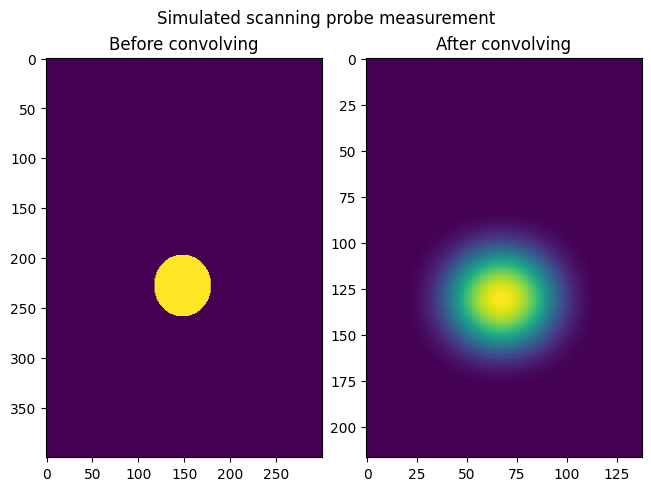

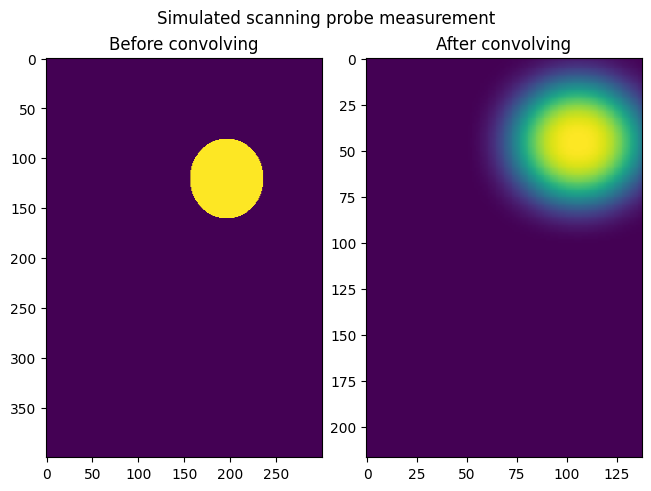

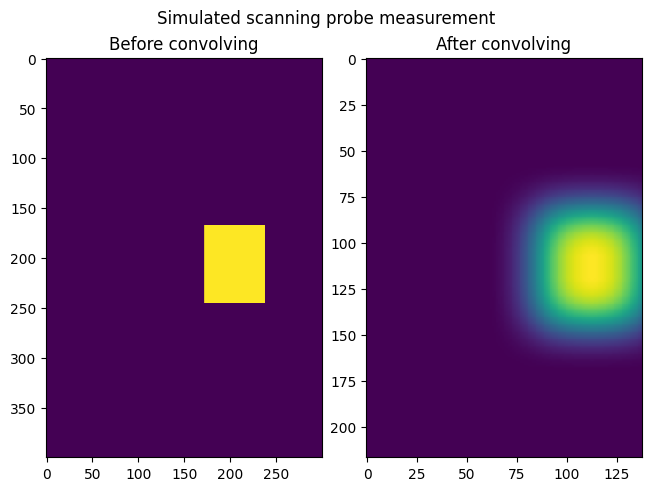

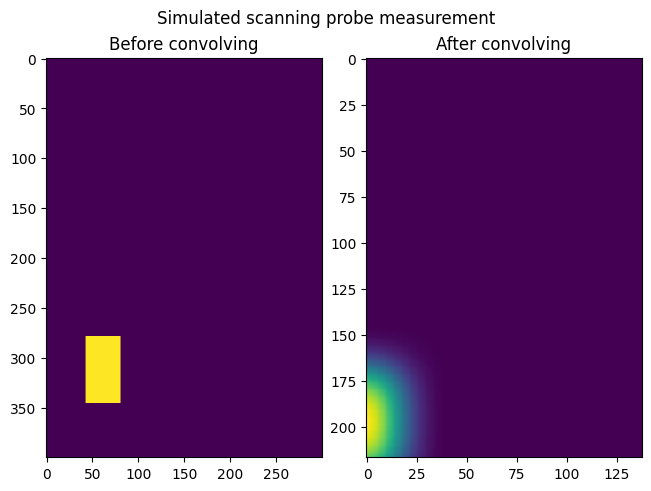

In [16]:
from scipy.signal import fftconvolve

# Use probe intensity (|probe|^2) as PSF, matching the forward model in enhance.py
probe_intensity = np.abs(probe) ** 2
probe_intensity = probe_intensity / probe_intensity.sum()

# Convolve full object with probe PSF, then sample at scan positions.
# conv_result[r, c] = integral of PSF * element_map_patch centred at (r, c)
element_maps_convolved = []
for element_map in element_maps_truth:
    conv_result = fftconvolve(element_map.counts_per_second, probe_intensity, mode="same")

    # Sample at each scan position (positions are already integer-valued from linspace,
    # but round to be safe)
    pos_idx = np.round(positions).astype(int)
    measurements_flat = conv_result[pos_idx[:, 0], pos_idx[:, 1]]

    # Reshape to (n_rows, n_cols). Raster scan order matches probe_positions order,
    # so this is directly visualizable.
    measurements = np.abs(measurements_flat.reshape(n_rows, n_cols))

    fig, ax = plt.subplots(1, 2, layout="compressed")
    plt.sca(ax[0])
    plt.title("Before convolving")
    plt.imshow(element_map.counts_per_second, aspect="auto")
    plt.sca(ax[1])
    plt.title("After convolving")
    ax[1].imshow(measurements, aspect="auto")
    plt.suptitle("Simulated scanning probe measurement")
    plt.show()

    element_maps_convolved += [ElementMap(element_map.name, measurements)]

### 5. Package data into `ptychozoon` objects

In [17]:
# package data
# ptycho
pixel_size_m = 1

probe_positions=positions-np.array(object_array.shape)/2

# probe_positions[:, 0]=probe_positions[-1::-1, 0]*1

ptycho_in = Product(
    probe_positions=probe_positions,
    # probe_positions=positions-np.array(object_array.shape)/2, 
    # probe_positions=(positions-np.array(object_array.shape)/2)[-1::-1] * 1, 
    # probe_positions=(positions-np.array(object_array.shape)/2) * np.array([-1, -1]),
    probe=probe[None],
    object_array=object_array,
    pixel_size_m=(pixel_size_m,) * 2,
    object_center_m=np.array([0, 0]),
)
# fluorescence
flourescence_in = FluorescenceDataset(element_maps_convolved)

# plt.imshow(np.angle(ptycho_in.object_array))
# plt.plot(
#     ptycho_in.probe_positions[:, 1] + object_array.shape[1] / 2,
#     ptycho_in.probe_positions[:, 0] + object_array.shape[0] / 2,
#     "k",
#     alpha=0.25,
# )
# plt.show()

## Run enhancement

### Define results plotting functions

In [8]:
def plot_result_images(
    ptycho_in: Product,
    element_map_truth: ElementMap,
    element_map_input: ElementMap,
    element_map_enhanced: ElementMap,
):
    fig, ax = plt.subplots(1, 4, layout="compressed", figsize=(10, 10))
    plt.sca(ax[0])
    plt.title("ptycho")
    plt.imshow(np.angle(ptycho_in.object_array))
    plt.sca(ax[1])
    plt.title(f"{element_map_truth.name}\ntruth")
    plt.imshow(element_map_truth.counts_per_second)
    # plt.colorbar()
    plt.sca(ax[2])
    plt.title(f"{element_map_input.name}\nconvolved")
    plt.imshow(element_map_input.counts_per_second, cmap="bone")
    # plt.colorbar()
    plt.sca(ax[3])
    plt.title(f"{element_map_enhanced.name}\nfluorescence-enhanced")
    plt.imshow(element_map_enhanced.counts_per_second)# cmap="viridis")
    # plt.colorbar()
    plt.show()

def plot_result_cross_sections(
    element_map_truth: ElementMap,
    element_map_input: ElementMap,
    element_map_enhanced: ElementMap,
    xrf_array_width_in_pixels: float,
):
    labels = ["convolved", "fluorescence-enhanced","truth"]
    arrays_in = [
        element_map_input.counts_per_second,
        element_map_enhanced.counts_per_second,
        element_map_truth.counts_per_second,
    ]
    slice_idx = []
    for i, arr in enumerate(arrays_in):
        if i != 2:
            slice_idx = np.unravel_index(np.argmax(arr), arr.shape)[0]
        if i == 0:
            x = np.linspace(-xrf_array_width_in_pixels/2, xrf_array_width_in_pixels/2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i])
        elif i == 1:
            w0 = len(arr[slice_idx])
            x = np.linspace(-w0/2, w0/2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], zorder=-4, alpha=.75)
        elif i == 2:
            w0 = len(arr[slice_idx])
            x = np.linspace(-w0/2, w0/2, len(arr[slice_idx]))
            plt.plot(x, arr[slice_idx], label=labels[i], zorder=-5, color="k")
    plt.grid(ls=":", zorder=-99)
    plt.legend()
    plt.show()


### results: barycentric

In [29]:
flourescence_result = VSPIFluorescenceEnhancingAlgorithm(max_iterations=100, damping_factor=0).enhance(
    flourescence_in,
    ptycho_in,
    use_gpu=False,
    # select_maps=['element_0', 'element_1'],
    settings=DeconvolutionEnhancementSettings(interpolation=InterpolationTypes.BARYCENTRIC)
)

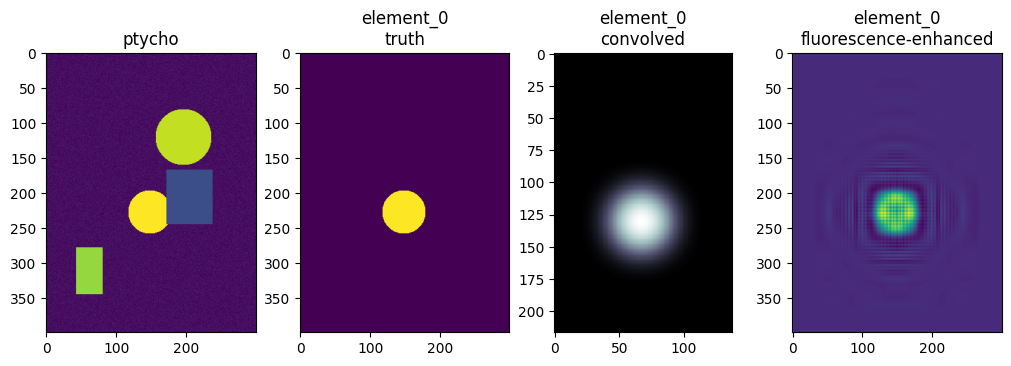

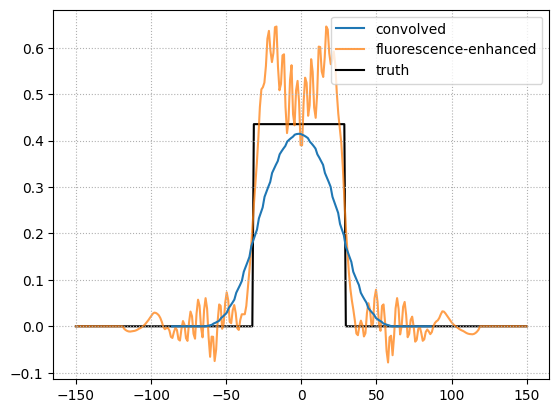

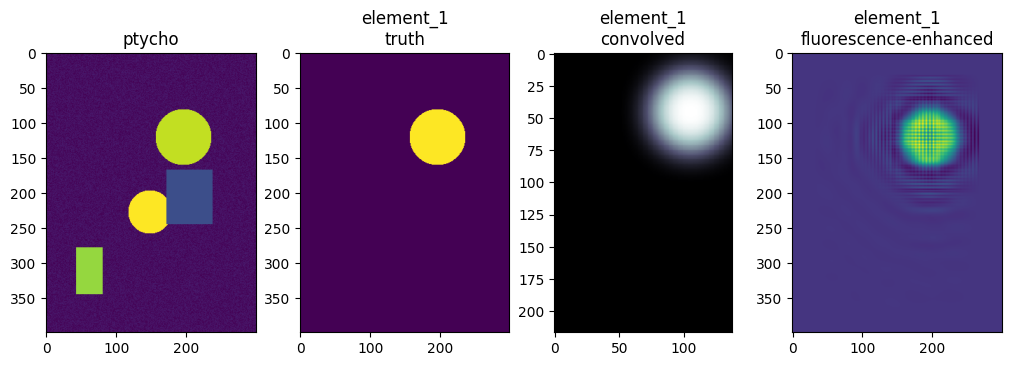

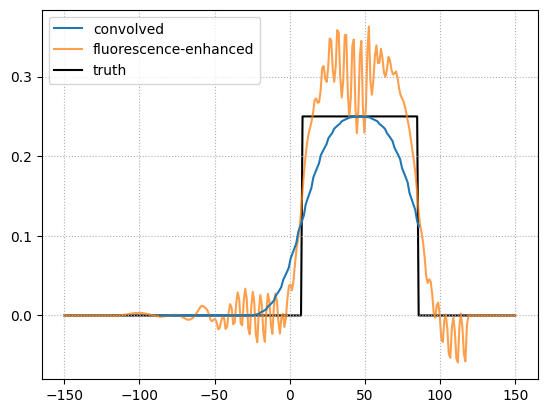

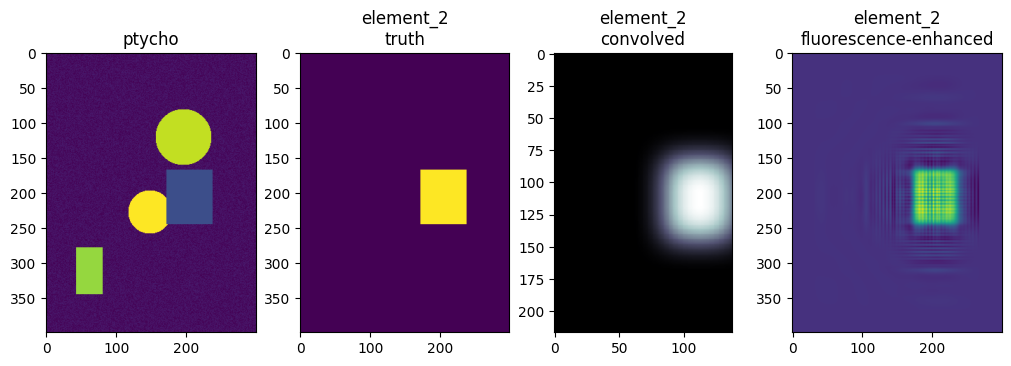

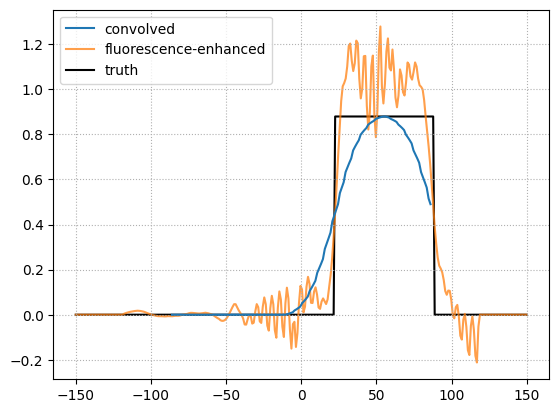

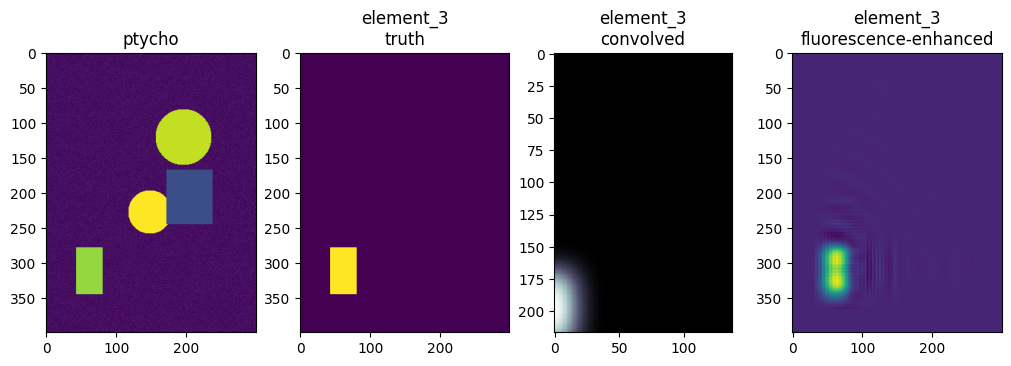

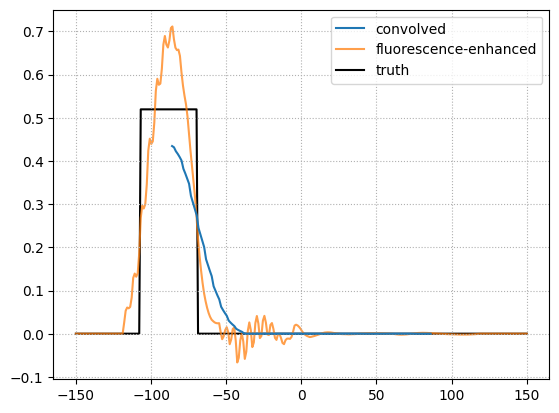

In [30]:
for i in range(len(flourescence_result.element_maps)):
    plot_result_images(
        ptycho_in,
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        flourescence_result.element_maps[i],
    )

    plot_result_cross_sections(
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        flourescence_result.element_maps[i],
        xrf_array_width_in_pixels=col_coords[-1] - col_coords[0],
    )

### results: fourier

In [31]:
flourescence_result = VSPIFluorescenceEnhancingAlgorithm(max_iterations=100, damping_factor=0.0).enhance(
    flourescence_in,
    ptycho_in,
    use_gpu=True,
    # select_maps=['element_0'],
    settings=DeconvolutionEnhancementSettings(interpolation=InterpolationTypes.FOURIER)
)

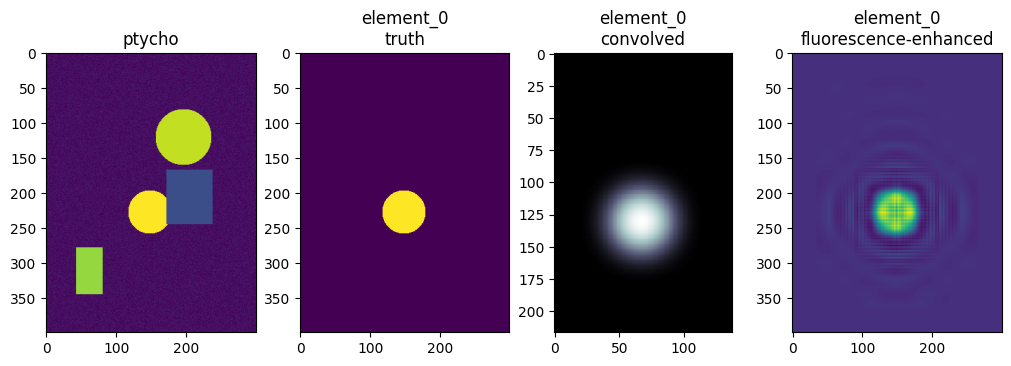

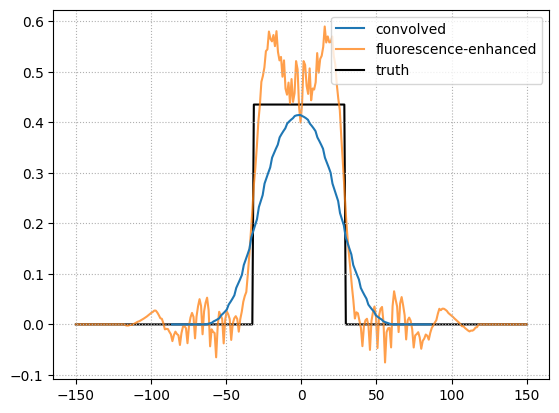

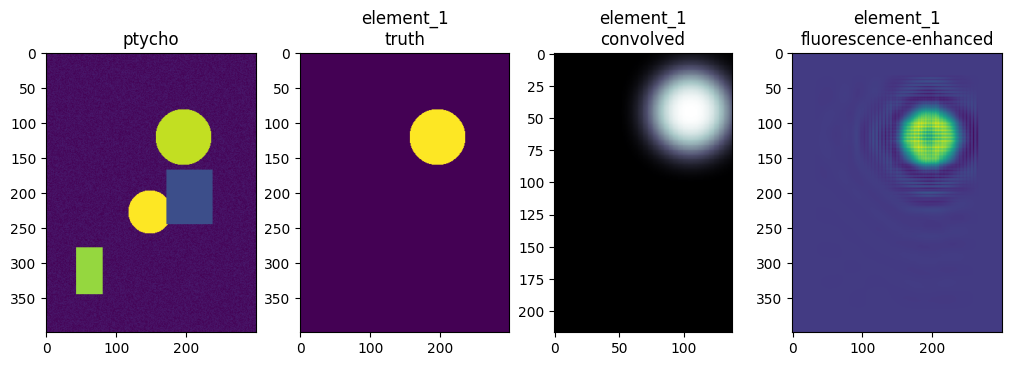

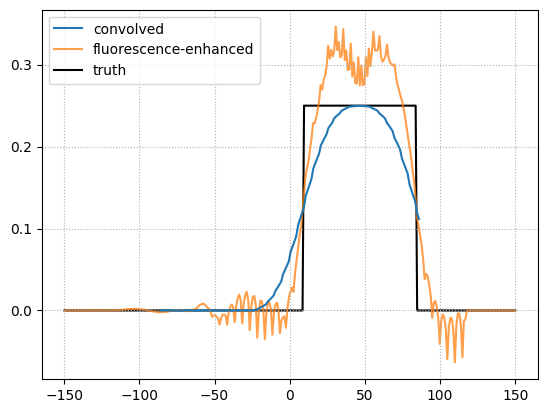

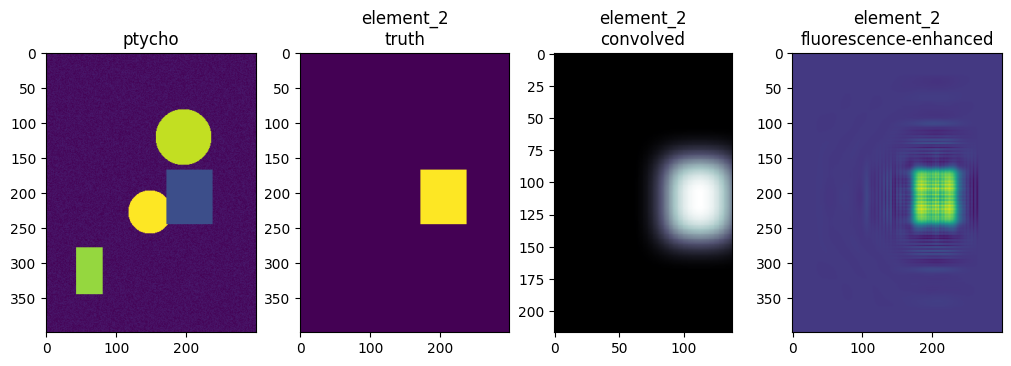

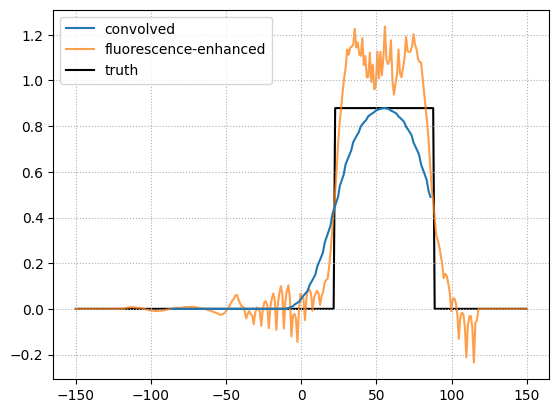

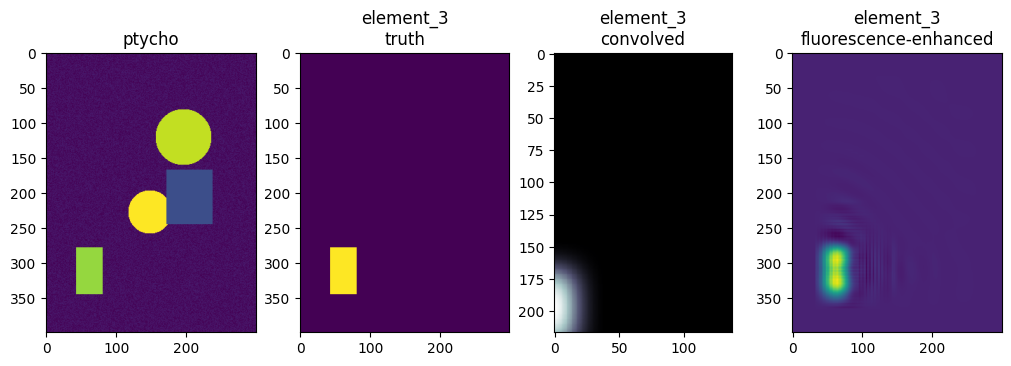

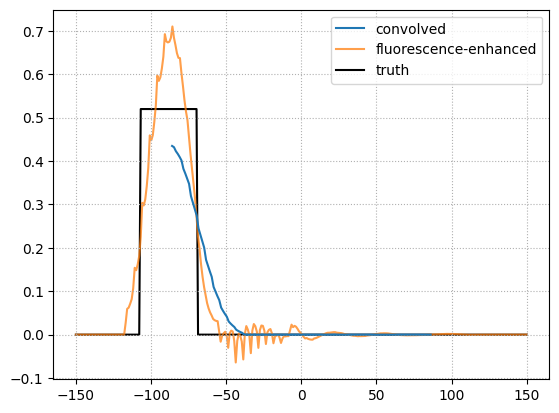

In [32]:
for i in range(len(flourescence_result.element_maps)):
    plot_result_images(
        ptycho_in,
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        flourescence_result.element_maps[i],
    )

    plot_result_cross_sections(
        element_maps_truth[i],
        flourescence_in.element_maps[i],
        flourescence_result.element_maps[i],
        xrf_array_width_in_pixels=col_coords[-1] - col_coords[0],
    )